In [1]:
import time
notebook_start = time.perf_counter()

# %pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift

import feos
import si_units as si
import numpy as np
import pandas as pd
import importlib.metadata
from pathlib import Path

# Import thermoift modules
from thermoift import KIJ
from thermoift.FeosPlugin import (
    RegistryManager,
    CompositionHandler,
    ParameterBuilder,
    PropertyCalculator,
    VLECalculator,
    InterfacialTensionCalculator,
    DataProcessor,
    PlottingEngine
)
from thermoift.semi_emperical_correlations import semi_emperical_correlations

print(f"FEOS version used: {importlib.metadata.version('feos')}")
KIJ_DIR = Path(KIJ.__file__).parent

FEOS version used: 0.9.4


In [2]:
COMPONENTS  = ["carbon dioxide", "hydrogen", "argon"]

# KIJ_map     = {
#                 ("CO2", "Ar")   : "constant",
#                 ("H2", "Ar")    : "linear",
#                 ("CO2", "H2")   : "linear"}

KIJ_map     = {
                ("CO2", "Ar")   : "zero",
                ("H2", "Ar")    : "zero",
                ("CO2", "H2")   : "zero"}

CO2_comp    = 0.95
feeds       = CompositionHandler.make_feeds([CO2_comp, 0.02, 0.03])
TEST_RUN    = False
verbose     = True
CSV_FOLDER  = "CSV"


K(300.0 K) =
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Symbolic K(T) matrix:


Matrix([
[0, 0, 0],
[0, 0, 0],
[0, 0, 0]])


Pair equations:


Eq(k_{CO2,H2}(T), 0)

Eq(k_{CO2,Ar}(T), 0)

Eq(k_{H2,Ar}(T), 0)

  i |         z1 |         z2 |         z3
---------------------------------------------------------
  1 |       0.9500       0.0200       0.0300


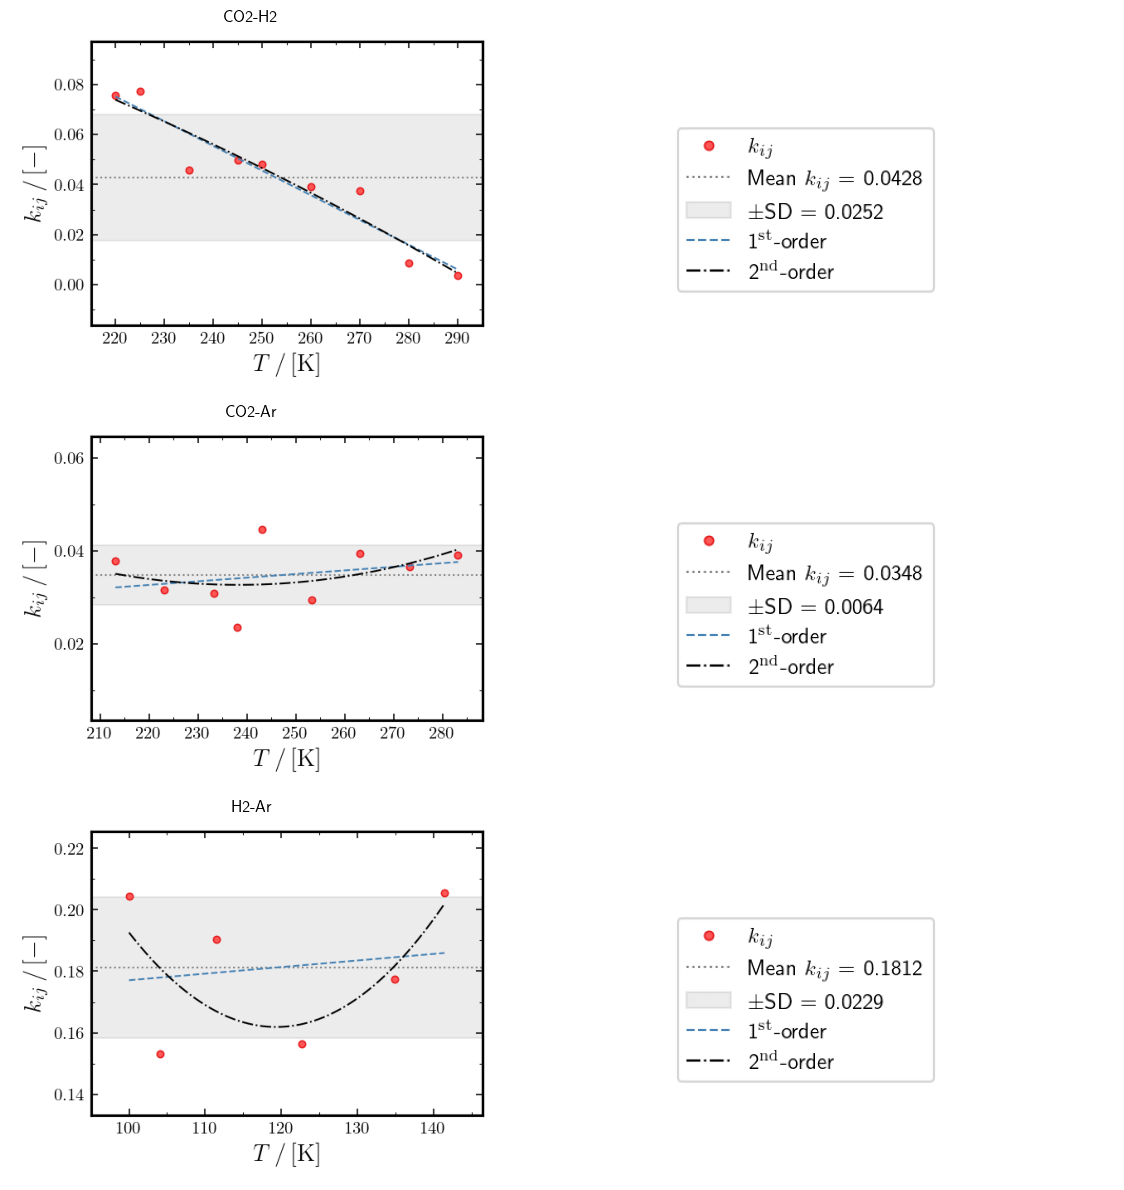

|component|molarweight|m|sigma|epsilon_k|
|-|-|-|-|-|
|carbon dioxide|43.99|2.53096|2.57855|153.31864|
|hydrogen|2.016|1.0|3.002|51.343|
|argon|39.962|1.0|3.37751|117.80903|

|component 1|component 2|k_ij|
|-|-|-|
|carbon dioxide|hydrogen|0.0|
|carbon dioxide|argon|0.0|
|hydrogen|argon|0.0|

In [3]:
builder             = KIJ.KIJMatrixBuilder(root = str(KIJ_DIR), kij_filename = "KIJ.json", verbose = False)
parameters          = ParameterBuilder.build_parameters(COMPONENTS, T_K= 300.0, kij_builder = builder, model_map = KIJ_map)  # Arbitrary T_K is to check whether KIJ are imported correctly
components          = RegistryManager.get_component_names(parameters)
KIJ_LABELS          = RegistryManager.kij_labels_from_names(COMPONENTS)

builder.build_and_display(components=KIJ_LABELS,model_map=KIJ_map,T_eval=300.0,show_matrix=True,show_pair_equations=True)
CompositionHandler.print_array2d(feeds)
builder.show_pair_plots(KIJ_LABELS, mode="all")

parameters

In [4]:
# TEST: FLASH and IFT computation settings

if TEST_RUN == True:
    T_initial   = 200
    P_TOL       = 1e-2          # Pressure [bar] tolerance for flash calculations
    T_STEP      = 1            # Temperature step for bubble/dew curves [K]
    P_STEP      = 1             # Pressure step for flash calculations [bar]
    lgrid       = 100           # Length of computational domain [Angstrom]
    ngrid       = 500           # Number of grid points for planar interface
    PT_results  = {}            # Store phase envelope results
    VLE_DFT_boundary = {}       # Store VLE-DFT boundary results
    
elif TEST_RUN == False:
    T_initial   = 200
    P_TOL       = 1e-4           
    T_STEP      = 1            
    P_STEP      = 1                 
    lgrid       = 100          
    ngrid       = 2048
    PT_results  = {}       
    VLE_DFT_boundary = {}   

In [5]:
# Parameters & EOS (T-dependent kij rebuilt per temperature)

for k, z in enumerate(feeds, start=1):
    
    # --- Normalize + mole amounts ---
    z = CompositionHandler.normalize_z(z)
    feed = CompositionHandler.compute_feed_moles(z)
    
    if verbose:
        print(f"\nFeed {k}: z = {z}")
    
    # --- Detect zero components and reduce if needed ---
    active_z, active_components, is_reduced = CompositionHandler.reduce_components(
        z, COMPONENTS, verbose=verbose
    )
    active_feed = CompositionHandler.compute_feed_moles(active_z)
    active_map = ParameterBuilder.reduce_kij_map(active_components, KIJ_map)
    
    # --- Critical point (use reference T for kij) ---
    parameters_ref = ParameterBuilder.build_parameters(
        active_components,
        T_K=T_initial,
        kij_builder=builder,
        model_map=active_map
    )
    eos = feos.HelmholtzEnergyFunctional.pcsaft(parameters_ref)
    
    try:
        CT, CP = VLECalculator.compute_critical_point(eos, active_z, T_guess=T_initial)
        
        if verbose:
            print(f"Critical Point: T = {CT/si.KELVIN:.2f} K, P = {CP/si.BAR:.2f} bar")
        
        # Compute bubble and dew curves with T-dependent kij
        T_values = range(int(T_initial), int(CT / si.KELVIN) + 1, T_STEP)
        
        T_bubble_all, P_bubble_all = [], []
        T_dew_all, P_dew_all = [], []
        
        for T_K in T_values:
            # Rebuild parameters and eos at each temperature
            parameters_T = ParameterBuilder.build_parameters(
                active_components,
                T_K=float(T_K),
                kij_builder=builder,
                model_map=active_map
            )
            eos_T = feos.HelmholtzEnergyFunctional.pcsaft(parameters_T)
            
            # Compute bubble and dew curves
            T_bub, P_bub = VLECalculator.compute_bubble_curve(eos_T, [T_K], active_feed, verbose=verbose)
            T_dew, P_dew = VLECalculator.compute_dew_curve(eos_T, [T_K], active_feed, verbose=verbose)
            
            T_bubble_all.extend(T_bub)
            P_bubble_all.extend(P_bub)
            T_dew_all.extend(T_dew)
            P_dew_all.extend(P_dew)
        
        # Store results
        PT_results[f"feed_{k}"] = {
            "z": [round(float(x), 6) for x in np.asarray(z, dtype=float)],
            "TC_K": round(float(CT / si.KELVIN), 2),
            "PC_bar": round(float(CP / si.BAR), 2),
            "bubble": [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_bubble_all, P_bubble_all)],
            "dew": [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_dew_all, P_dew_all)],
        }
    
    except Exception as e:
        print(f"Feed {k}: z = {z}")
        print("Critical point computation failed:", e)


Feed 1: z = [0.95 0.02 0.03]
Critical Point: T = 305.84 K, P = 91.04 bar
Bubble calculation failed at T = 297 K: Iteration resulted in trivial solution.
Bubble calculation failed at T = 298 K: Iteration resulted in trivial solution.
Dew calculation failed at T = 301 K: Iteration resulted in trivial solution.
Bubble calculation failed at T = 302 K: Iteration resulted in trivial solution.
Dew calculation failed at T = 303 K: Iteration resulted in trivial solution.
Bubble calculation failed at T = 305 K: Iteration resulted in trivial solution.
Dew calculation failed at T = 305 K: Iteration resulted in trivial solution.


In [6]:
# IFT computation at bubble and dew points only

sec = semi_emperical_correlations(n_grid=ngrid, l_grid=lgrid)

for feed_key, feed in PT_results.items():
    
    TP_z = np.array(feed.get("z", []))
    CT = feed["TC_K"] * si.KELVIN
    CP = feed["PC_bar"] * si.BAR
    
    # --- Detect zero components and reduce if needed ---
    active_z, active_components, is_reduced = CompositionHandler.reduce_components(
        TP_z, COMPONENTS, verbose=verbose)
    active_feed = CompositionHandler.compute_feed_moles(active_z)
    active_map = ParameterBuilder.reduce_kij_map(active_components, KIJ_map)
    
    # Prepare bubble/dew dictionaries
    bub = {int(round(pt["T_K"])): float(pt["P_bar"]) for pt in feed.get("bubble", [])}
    dew = {int(round(pt["T_K"])): float(pt["P_bar"]) for pt in feed.get("dew", [])}
    common_T = sorted(set(bub) & set(dew))
    
    # Initialize storage for boundary IFT data
    VLE_DFT_boundary[feed_key] = {
        "z": TP_z.tolist(),
        "bubble_point_IFT": [],
        "dew_point_IFT": []
    }
    
    print(f"\n{feed_key}: Computing IFT at bubble and dew points...")
    
    if common_T:
        for T in common_T:
            
            # Rebuild parameters and eos at this temperature
            parameters_T = ParameterBuilder.build_parameters(
                active_components,
                T_K=float(T),
                kij_builder=builder,
                model_map=active_map
            )
            eos_T = feos.HelmholtzEnergyFunctional.pcsaft(parameters_T)
            molar_masses = PropertyCalculator.molar_masses(parameters_T)
            
            # --- Pure CO2 properties at this temperature ---
            gamma0_CO2, rhoL0_CO2, rhoV0_CO2, Tc_CO2, Pc_CO2, Psat_CO2 = \
                sec._pure_component_cDFT("carbon dioxide", float(T))
            
            P_b = bub[T]
            P_d = dew[T]
            
            if P_b >= P_d:
                
                # Compute IFT at bubble point (P_b - P_TOL) and dew point (P_d + P_TOL)
                boundary_pressures = [
                    ("bubble", P_b - P_TOL),
                    ("dew", P_d + P_TOL)
                ]
                
                for point_type, P in boundary_pressures:
                    
                    if verbose:
                        print(f"T = {T} K | {point_type} point | P_flash = {P:.4f} bar")
                    
                    # --- TP flash using VLECalculator ---
                    try:
                        eq, x, y, liquid_density, vapor_density = VLECalculator.tp_flash(
                            eos_T, T*si.KELVIN, P*si.BAR, active_z*si.MOL, molar_masses
                        )
                    except Exception as e:
                        print(f"TP flash failed at {point_type} point: T = {T} K, P = {P:.4f} bar: {e}")
                        continue
                    
                    # --- Planar interface & surface tension ---
                    interface = InterfacialTensionCalculator.build_planar_interface(
                        eq, critical_temperature=CT, n_grid=ngrid, l_grid=lgrid
                    )
                    
                    try:
                        gamma_mN_m, interfacial_thickness_nm, enrichment = \
                            InterfacialTensionCalculator.solve_interface_properties(interface)
                    except Exception as e:
                        print(f"IFT calculation failed at {point_type} point: T = {T} K, P = {P:.4f} bar: {e}")
                        gamma_mN_m = np.nan
                        interfacial_thickness_nm = np.nan
                        enrichment = tuple(np.nan for _ in active_components)
                    
                    row_data = DataProcessor.assemble_row(
                        T, P, active_z, CT, CP, P_b, P_d, liquid_density, vapor_density,
                        x, y, gamma_mN_m, interfacial_thickness_nm, active_components, enrichment,
                        gamma0_CO2=gamma0_CO2,
                        rhoL0_CO2_mol_cm3=rhoL0_CO2,
                        rhoV0_CO2_mol_cm3=rhoV0_CO2,
                        Tc_CO2=Tc_CO2,
                        Psat_CO2=Psat_CO2,
                        ML_mode=False)
                    
                    if point_type == "bubble":
                        VLE_DFT_boundary[feed_key]["bubble_point_IFT"].append(row_data)
                    else:
                        VLE_DFT_boundary[feed_key]["dew_point_IFT"].append(row_data)
                    
                    print(f"  T = {T} K | {point_type:6s} | P = {P:.4f} bar | gamma = {gamma_mN_m:.4f} mN/m")

Path(CSV_FOLDER).mkdir(parents=True, exist_ok=True)

for feed_key, data in VLE_DFT_boundary.items():
    for point_type in ["bubble_point_IFT", "dew_point_IFT"]:
        if data[point_type]:
            df = pd.DataFrame(data[point_type])
            filename = f"{CSV_FOLDER}/{feed_key}_{point_type}.csv"
            df.to_csv(filename, index=False)


feed_1: Computing IFT at bubble and dew points...
T = 200 K | bubble point | P_flash = 60.0615 bar
  T = 200 K | bubble | P = 60.0615 bar | gamma = 14.8264 mN/m
T = 200 K | dew point | P_flash = 2.5235 bar
  T = 200 K | dew    | P = 2.5235 bar | gamma = 19.8841 mN/m
T = 201 K | bubble point | P_flash = 59.6964 bar
  T = 201 K | bubble | P = 59.6964 bar | gamma = 14.6801 mN/m
T = 201 K | dew point | P_flash = 2.6560 bar
  T = 201 K | dew    | P = 2.6560 bar | gamma = 19.6469 mN/m
T = 202 K | bubble point | P_flash = 59.3449 bar
  T = 202 K | bubble | P = 59.3449 bar | gamma = 14.5325 mN/m
T = 202 K | dew point | P_flash = 2.7939 bar
  T = 202 K | dew    | P = 2.7939 bar | gamma = 19.4101 mN/m
T = 203 K | bubble point | P_flash = 59.0067 bar
  T = 203 K | bubble | P = 59.0067 bar | gamma = 14.3835 mN/m
T = 203 K | dew point | P_flash = 2.9374 bar
  T = 203 K | dew    | P = 2.9374 bar | gamma = 19.1739 mN/m
T = 204 K | bubble point | P_flash = 58.6817 bar
  T = 204 K | bubble | P = 58.68

/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:178: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=300.0 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:178: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=304.0 K: `PureFMTAssocFunctional` encountered illegal values during the iteration.
  warnings.warn(


In [7]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 1.73 minutes
